**This notebook demonstrates how to create a GlacierMIP4 compliant dataset.**
**Also, we show and explain the difference between cf point and interval variables.**

> First, we create a timeseries that we can use for our nc file.
> It is cf compliant and includes bounds for continuous variables.

In [1]:
from src.timeseries import get_days_and_bounds

frequency = "annual"

EPOCH_DATE = "1850-01-01"
START_DATE = "2000-01-01"
END_DATE = "2010-01-01"

epoch, time, bounds = get_days_and_bounds(
    start_date=START_DATE,
    end_date=END_DATE,
    epoch_date=EPOCH_DATE,
    frequency=frequency,
)

> Then, we create an empty nc-file structure using the timeseries. So far, the dataset does not include any data variables.

In [2]:
from src.dataset_builder import create_template_nc

annual_ds = create_template_nc(
    time=time,
    bounds=bounds,
    frequency=frequency,
    epoch=epoch,
)

annual_ds

<xarray.Dataset> Size: 134B
Dimensions:      (time: 11, nv: 2)
Coordinates:
  * time         (time) int32 44B 54786 55152 55517 55882 ... 57708 58074 58439
  * nv           (nv) int8 2B 0 1
Data variables:
    time_bounds  (time, nv) int32 88B 54421 54786 54786 ... 58074 58074 58439

> Now, we add the data variables. The variables are defined in a separate file and the definitions are taken directly from the GlacierMIP4 protocol.

In [3]:
import yaml
from src.dataset_builder import add_variable

glacier_mip_vars = "variable_definitions.yml"

with open(glacier_mip_vars, "r") as f:
    VARS = yaml.safe_load(f)["variables"][frequency]

ds = annual_ds

for var_key, meta in VARS.items():

    ds = add_variable(
        ds,
        var_key,
        meta=meta,
        time_dim="time",
    )

ds

<xarray.Dataset> Size: 310B
Dimensions:      (time: 11, nv: 2)
Coordinates:
  * time         (time) int32 44B 54786 55152 55517 55882 ... 57708 58074 58439
  * nv           (nv) int8 2B 0 1
Data variables:
    time_bounds  (time, nv) int32 88B 54421 54786 54786 ... 58074 58074 58439
    area         (time) float32 44B 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
    mass         (time) float32 44B 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
    mass_bsl     (time) float32 44B 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
    frontal_abl  (time) float32 44B 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0

> Let's fill the data vars with random data.

In [4]:
import numpy as np

for var_name in ds.data_vars:
    # Exclude time bounds
    if "bounds" in var_name:
        continue

    shape = ds[var_name].shape

    ds[var_name].values = np.random.uniform(
        0,
        10,
        size=shape,
    ).astype(ds[var_name].dtype)

ds.to_netcdf("tmp.nc")

ds

<xarray.Dataset> Size: 310B
Dimensions:      (time: 11, nv: 2)
Coordinates:
  * time         (time) int32 44B 54786 55152 55517 55882 ... 57708 58074 58439
  * nv           (nv) int8 2B 0 1
Data variables:
    time_bounds  (time, nv) int32 88B 54421 54786 54786 ... 58074 58074 58439
    area         (time) float32 44B 7.916 8.991 5.789 9.53 ... 9.266 8.093 5.262
    mass         (time) float32 44B 2.697 0.8364 2.77 ... 3.468 0.09729 9.477
    mass_bsl     (time) float32 44B 5.439 7.7 4.687 1.109 ... 8.476 6.002 9.728
    frontal_abl  (time) float32 44B 3.722 5.352 3.543 ... 7.692 2.485 6.778

> Now we can plot the data using the cf compliant iris package and a custom function.

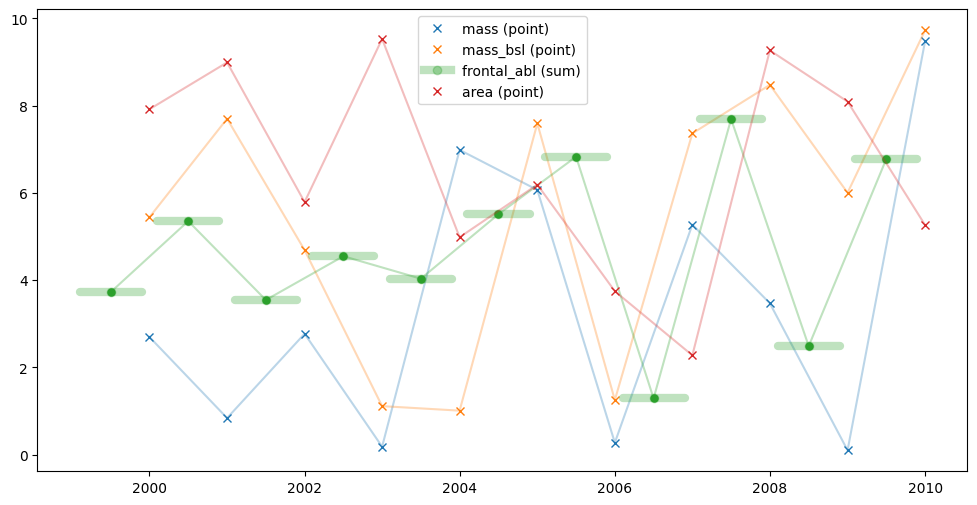

In [7]:
import iris
from src.visualize import plot_cf_cubes

cubes = iris.load("tmp.nc")

plot_cf_cubes(cubes)

Please note that the frontal ablation is displayed differently here. This illustrates the difference between **Point** and **Interval** (SUM/AVG/MEAN/MIN/MAX) variables.

- **Point** variables represent an instantaneous state at the given timestep.
- **Interval** variables represent values over the time interval defined by the `time_bounds`.

When adding your data, please ensure that:

- **Point** variables refer to the `time` dimension
- **Interval** variables refer to the `time_bounds` dimension

**Notice that the Interval variables start earlier in time than the Point variables, while ending at the same timestep.**


> Lastly, we demonstrate the usage of a high level shortcut for generating the template file.

In [6]:
from src.create_template import create_glaciermip_dataset

ds = create_glaciermip_dataset(
    frequency="annual",
    start_date="2000-01-01",
    end_date="2010-01-01",
    epoch_date="1850-01-01",
    variable_yml="variable_definitions.yml",
)

ds

<xarray.Dataset> Size: 310B
Dimensions:      (time: 11, nv: 2)
Coordinates:
  * time         (time) int32 44B 54786 55152 55517 55882 ... 57708 58074 58439
  * nv           (nv) int8 2B 0 1
Data variables:
    time_bounds  (time, nv) int32 88B 54421 54786 54786 ... 58074 58074 58439
    area         (time) float32 44B 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
    mass         (time) float32 44B 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
    mass_bsl     (time) float32 44B 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
    frontal_abl  (time) float32 44B 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0

> **In another notebook, we show how to add real data to the generated GlacierMIP4 data variables.**